<a href="https://colab.research.google.com/github/vcellmike/PatternsFormation/blob/main/Working/To_Silico_Conversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! git clone https://github.com/vcellmike/PatternsFormation.git
! echo "Git Complete"

Cloning into 'PatternsFormation'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 108 (delta 26), reused 11 (delta 3), pack-reused 14 (from 1)
Receiving objects: 100% (108/108), 75.91 MiB | 18.57 MiB/s, done.
Resolving deltas: 100% (29/29), done.
Git Complete


In [ ]:
! unzip /content/PatternsFormation/Toybox/real_images_6-29-25.zip -d /content/PatternsFormation/UnzippedRealImages/
! echo "Unzip Complete"

Archive:  /content/PatternsFormation/Toybox/real_images_6-29-25.zip
   creating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/
  inflating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/1.png  
  inflating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/10.png  
  inflating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/11.png  
  inflating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/12.png  
  inflating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/13.png  
  inflating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/2.png  
  inflating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/3.png  
  inflating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/4.png  
  inflating: /content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/5.png  
  inflating: /content/PatternsFormation/UnzippedRealImages/real_i

In [ ]:
############## Define paths ####################

import os

path = "/content/PatternsFormation/UnzippedRealImages/real_images_6-29-25"

filenames = []
filenames_trunc = []

for filename in sorted(os.listdir(path), key=lambda x: int(x.split(".")[0])):
    if os.path.isfile(os.path.join(path, filename)):
        filenames.append(path + '/' + filename)
        filenames_trunc.append(filename)

In [ ]:
import pandas as pd

RealImages_df = pd.DataFrame(
    {
        'filename': filenames,
        'filenames_trunc' : filenames_trunc
    }
)

RealImages_df['filename'][0]
RealImages_df

,filename,filenames_trunc
0,/content/PatternsFormation/UnzippedRealImages/...,1.png
1,/content/PatternsFormation/UnzippedRealImages/...,2.png
2,/content/PatternsFormation/UnzippedRealImages/...,3.png
3,/content/PatternsFormation/UnzippedRealImages/...,4.png
4,/content/PatternsFormation/UnzippedRealImages/...,5.png
5,/content/PatternsFormation/UnzippedRealImages/...,6.png
6,/content/PatternsFormation/UnzippedRealImages/...,7.png
7,/content/PatternsFormation/UnzippedRealImages/...,8.png
8,/content/PatternsFormation/UnzippedRealImages/...,9.png
9,/content/PatternsFormation/UnzippedRealImages/...,10.png


In [ ]:
### Utility Functions

from PIL import Image, ImageEnhance
import math

color_rgb = {
    "red": (255, 0, 0),
    "yellow": (255, 255, 0),
    "orange": (255, 165, 0),
    "white": (255, 255, 255),
    "blue": (0, 0, 255)
}

contrast_factor = 2

def pull_from_df(index, show=True):
  path = RealImages_df.iloc[index]['filename']
  img_obj = Image.open(path)
  if show:
    display(img_obj)
  else:
    pass
  return path,img_obj

def convert_to_grayscale(img_obj):
  img_obj = img_obj.convert('L')
  return img_obj

def color_distance(c1, c2):
    # Euclidean distance in RGB space
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(c1, c2)))
""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
def round_pixels_by_intensity(image_obj, threshold, display_enhanced=True, enhance=True, enhance_factor=1.5):
  """
    Multiple inputs:
      Image Object - the PIL Image object
      Threshold - The threshold at which a pixel is either filled with white or black
      Display_Enhanced - Whether to display the enhanced image. Defaults to True. Only used if enhance is True.
      Enhance - Whether to enhance the image. Defaults to True.
      Enhance_Factor - The factor to enhance the image by. Defaults to 1.5
  """
  if enhance:
    enhancer = ImageEnhance.Contrast(image_obj)
    img_enhanced = enhancer.enhance(enhance_factor)
    if display_enhanced: display(img_enhanced)
    image_obj = img_enhanced
  else:
    pass
  image_obj = image_obj.convert('L').point(lambda x: 0 if x < threshold else 255, '1')
  return image_obj
""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
def round_pixels_by_color(image_obj, background_color='yellow', spot_color='orange'):
  try:
    spot_rgb = color_rgb[spot_color]
    bg_rgb = color_rgb[background_color]
  except Exception as e:
    print("One (or both) color(s) does not exist.")
    raise e

  # Ensure the image is in RGB mode for color distance calculation
  if image_obj.mode != 'RGB':
      image_obj = image_obj.convert('RGB')

  # Create a new blank image in RGB mode
  rounded_image = Image.new('RGB', image_obj.size)
  pixels = rounded_image.load()

  for i in range(image_obj.size[0]):
    for j in range(image_obj.size[1]):
      # Get the pixel value as an RGB tuple
      pixel_rgb = image_obj.getpixel((i, j))

      # Calculate Euclidean distance to background and spot colors
      dist_bg = color_distance(pixel_rgb, bg_rgb)
      dist_spot = color_distance(pixel_rgb, spot_rgb)

      # Assign black or white based on closeness
      if dist_spot < dist_bg:
          pixels[i, j] = (0, 0, 0) # Black
      else:
          pixels[i, j] = (255, 255, 255) # White

  return rounded_image


def save_image(img_obj, path):
  img_obj.save(path)

#path, img_obj = pull_from_df(1)

### Current Status
Below are the current statuses of the images.

**Note**:

Blackwashed = too dark (ie. pigment is overexpressed)

Whitewashed = too light (ie. pigment is underexpressed)

1.png - Satisfactory

2 - Satisfactory

3 - Blackwashed

4 - Blackwashed

5- Whitewashed

6 - Misc.

7 - Satisfactory

8 - Blackwashed

9 - Whitewashed

10 - Blackwashed (detects 1 spot that does not exist)

11 - Blackwashed

12 - Blackwashed

13 - Blackwashed

**Complete Count:**
 - 6/13 - Blackwashed
 - 3/13 - Whitewashed
 - 3/13 - Satisfactory
 - 1/13 - Miscellaneous issues

**Hypothesis**: Increasing the threshold will eliminate blackwashing/oversensitivity and improve accuracy. To be tested 7/2/2025.

/content/PatternsFormation/UnzippedRealImages/real_images_6-29-25/8.png


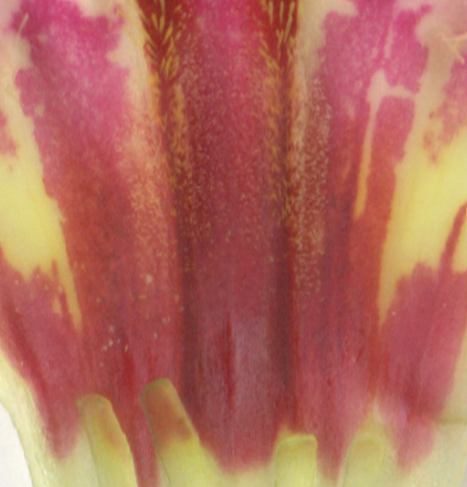

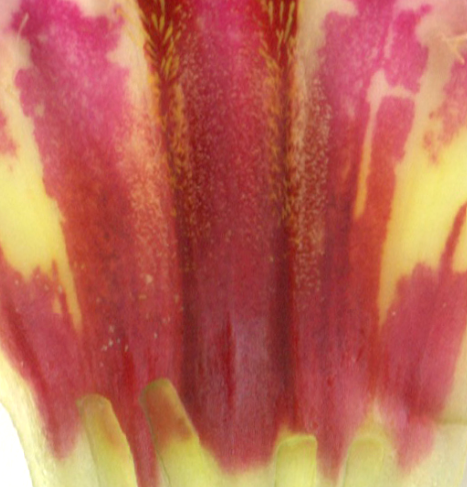

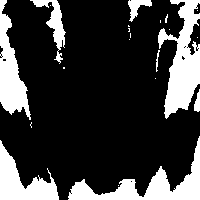

In [ ]:
# Images
num_images = 13

# Bring this number up
# Goal: fine tune this number so that the function converts the images more properly.
default_threshold = 163

#Experimentation:
  # seperate threshold values per image
  # segmentation of images through UNet or basic segmentation

def to_silico(i,show=False, enhance=False, contrast_factor=1.5, threshold=default_threshold):
  """
    i - The location of the image in the data frame
    enhance - Whether to enhance the image. Defaults to True.
    show - Whether to display the image. Defaults to False.
    threshold - The threshold at which a pixel is either filled with white or black. Defaults to 163.
    contrast_factor - The factor to enhance the image by. Defaults to 1.5
  """
  filename, image_obj = pull_from_df(i, show=show)
  print(filename)
  display(image_obj)
  new_image_obj = round_pixels_by_intensity(image_obj, threshold=threshold, enhance=enhance, enhance_factor=contrast_factor)
  new_image_obj = new_image_obj.resize((200,200), Image.Resampling.LANCZOS) # Assign the resized image back to image_obj
  display(new_image_obj)

#to_silico(0, enhance=False, threshold=163)
#to_silico(1, enhance=False, threshold=163)
#to_silico(2, enhance=False, threshold=145)
#to_silico(3, enhance=False, threshold=123)
#to_silico(4, threshold=163) - has artifacts (eg. hair) in the image which make conversion difficult
#to_silico(5, threshold=163) - has artifacts (eg. hair) in the image which make conversion difficult
#to_silico(6, threshold=175)
to_silico(7, enhance=True, contrast_factor=1.2 , threshold=162)
